# EMSCAD Traditional ML Live Demo

This notebook demonstrates a judge-friendly scoring system with three layers:

- `Trust Score` = ML legitimacy + fraud heuristics
- `Quality Score` = posting quality heuristics
- `Final Opportunity Score` = weighted trust/quality ranking with trust safeguards


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent

SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print('Working directory:', Path.cwd())
print('Project root:', ROOT)
print('src on path:', SRC.exists())


Working directory: /Users/shahan/Documents/Remote Job Scam-NotScam
Project root: /Users/shahan/Documents/Remote Job Scam-NotScam
src on path: True


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from job_fraud_detector.inference import FraudDetector
from job_fraud_detector.live_sources import SOURCES, fetch_jobs_from_sources, score_live_jobs
from job_fraud_detector.rules import evaluate_job_posting


In [3]:
ARTIFACTS_DIR = ROOT / 'artifacts' / 'emscad_light_model'
MODEL_NAME = 'voting_soft'  # or None to use selected champion

detector = FraudDetector.from_artifacts(ARTIFACTS_DIR, model_name=MODEL_NAME)

metrics_path = ARTIFACTS_DIR / 'metrics.json'
comparison_path = ARTIFACTS_DIR / 'model_comparison.csv'
cm_path = ARTIFACTS_DIR / 'confusion_matrix_test.png'

for p in [metrics_path, comparison_path, cm_path]:
    print(f'{p.name}:', 'FOUND' if p.exists() else 'MISSING')

metrics = json.loads(metrics_path.read_text())
selected_model = metrics['selected_model_name']
print()
print('Selected model from training:', selected_model)
print('Loaded model for inference:', detector.model_name or selected_model)
print('Threshold:', round(detector.threshold, 4))
print('Threshold mode:', metrics['threshold_selection']['mode'])


metrics.json: FOUND
model_comparison.csv: FOUND
confusion_matrix_test.png: FOUND

Selected model from training: linsvc_cal_tfidf
Loaded model for inference: voting_soft
Threshold: 0.6615
Threshold mode: target_recall_met


## Scoring Framework Used in This Demo

- `Trust Score = 0.45 * RuleEngineScore + 0.55 * MLLegitimacyScore`
- `Quality Score` uses only rules (transparency, specificity, remote clarity, apply experience, freshness)
- `Final Opportunity Score = 0.70 * Trust + 0.30 * Quality`
- If `Trust < 50`, final is capped below 50

Hard trust caps used for high-risk scam signals:

- upfront fee / pay-to-work language: trust capped to 10
- fake-check patterns: trust capped to 20
- task-scam patterns: trust capped to 20
- messaging-app + text-only interview pattern: trust capped to 25


In [4]:
_probe = evaluate_job_posting(
    {
        'title': 'Example role',
        'description': 'Example description with responsibilities and requirements',
        'requirements': '3+ years experience',
        'location': 'Remote',
        'employment_type': 'Full-time',
        'telecommuting': 1,
    },
    ml_fraud_probability=0.35,
)

display(pd.DataFrame(_probe['weights']['trust_blend'].items(), columns=['Trust blend term', 'weight']))
display(pd.DataFrame(_probe['weights']['final_blend'].items(), columns=['Final blend term', 'weight']))


,Trust blend term,weight
0,rule_engine_score,0.45
1,ml_legitimacy_score,0.55


,Final blend term,weight
0,trust_score,0.7
1,quality_score,0.3


In [5]:
# Model comparison table saved by training
comparison_df = pd.read_csv(comparison_path)
comparison_df


,model_id,threshold,threshold_mode,val_precision,val_recall,val_f1,val_pr_auc,val_roc_auc,test_precision,test_recall,test_f1,test_pr_auc,test_roc_auc
0,logreg_tfidf,0.605630,target_recall_met,0.780000,0.900000,0.835714,0.939157,0.995189,0.774834,0.900000,0.832740,0.932701,0.993788
1,sgd_log_tfidf,0.702392,target_recall_met,0.929134,0.907692,0.918288,0.963460,0.997052,0.918699,0.869231,0.893281,0.948727,0.994945
2,linsvc_cal_tfidf,0.424533,target_recall_met,0.959677,0.915385,0.937008,0.971808,0.997754,0.940678,0.853846,0.895161,0.958380,0.995361
3,cnb_bow,0.995318,target_recall_met,0.795918,0.900000,0.844765,0.831654,0.991085,0.711538,0.853846,0.776224,0.757464,0.980489
4,voting_soft,0.661507,target_recall_met,0.951220,0.900000,0.924901,0.963815,0.996929,0.924370,0.846154,0.883534,0.943651,0.994680


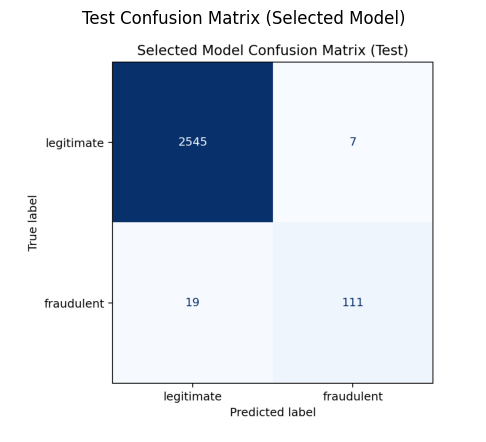

In [6]:
# Confusion matrix (selected model on test split)
img = plt.imread(cm_path)
plt.figure(figsize=(6.4, 5.2))
plt.imshow(img)
plt.axis('off')
plt.title('Test Confusion Matrix (Selected Model)')
plt.show()


## Helper Functions For Understandable Score Delivery


In [7]:
TRUST_COMPONENT_LABELS = {
    'identity_apply_integrity': 'Identity & Apply Integrity',
    'communication_safety': 'Communication Safety',
    'monetary_safety': 'Monetary Safety',
    'company_evidence': 'Company Evidence',
}

QUALITY_COMPONENT_LABELS = {
    'transparency': 'Transparency',
    'role_specificity': 'Role Specificity',
    'remote_clarity': 'Remote Clarity',
    'apply_experience': 'Apply Experience',
    'freshness': 'Freshness',
}


def _to_list(value):
    if isinstance(value, list):
        return value
    if value is None:
        return []
    return [str(value)]


def score_postings(postings, with_explanations=False, num_samples=1200):
    rows = []
    for i, posting in enumerate(postings, start=1):
        ml = detector.predict_posting(
            posting,
            with_explanation=with_explanations,
            num_features=10,
            num_samples=num_samples,
        )
        rule = evaluate_job_posting(posting, ml_fraud_probability=ml['fraud_probability'])
        rows.append({'example': i, **posting, **ml, **rule})
    return rows


def _component_frame(component_scores, maxima, labels):
    out = []
    for key, max_score in maxima.items():
        score = float(component_scores.get(key, 0.0) or 0.0)
        pct = (100.0 * score / max_score) if max_score else 0.0
        out.append(
            {
                'component': labels.get(key, key),
                'score': round(score, 2),
                'max_score': round(max_score, 2),
                'pct_of_component': round(pct, 1),
            }
        )
    return pd.DataFrame(out)


def build_reasoning_summary(row):
    risk_flags = _to_list(row.get('risk_flags'))
    positives = _to_list(row.get('positive_evidence'))
    hard_caps = _to_list(row.get('hard_caps'))

    hard_cap_text = ''
    if hard_caps:
        reasons = [hc.get('reason', '') for hc in hard_caps if isinstance(hc, dict)]
        reasons = [r for r in reasons if r]
        if reasons:
            hard_cap_text = 'Hard cap triggered: ' + '; '.join(reasons[:2])

    risk_text = 'No major risk flags.'
    if risk_flags:
        risk_text = 'Risks: ' + '; '.join(risk_flags[:3])

    pos_text = 'Limited positive evidence.'
    if positives:
        pos_text = 'Positives: ' + '; '.join(positives[:3])

    summary = (
        f"Trust {row.get('trust_score', 0):.1f} (Rule {row.get('rule_engine_score', 0):.1f}, "
        f"ML legitimacy {row.get('ml_legitimacy_score', 0):.1f}); "
        f"Quality {row.get('quality_score', 0):.1f}; "
        f"Final {row.get('final_opportunity_score', 0):.1f} ({row.get('badge', '')}). "
        f"{hard_cap_text} {risk_text} {pos_text}"
    )
    return ' '.join(summary.split())


def score_overview_table(df):
    if df.empty:
        return pd.DataFrame()

    source_rows = df.reset_index(drop=True)
    out = source_rows.copy()

    # Live-source rows do not always include 'example'; create deterministic display IDs.
    if 'example' not in out.columns:
        out.insert(0, 'example', out.index + 1)

    preferred_cols = [
        'example',
        'source',
        'title',
        'fraud_probability',
        'rule_engine_score',
        'ml_legitimacy_score',
        'trust_score',
        'quality_score',
        'final_opportunity_score',
        'badge',
        'trust_cap_applied',
        'final_cap_applied',
    ]
    available_cols = [col for col in preferred_cols if col in out.columns]
    out = out[available_cols].copy()

    out['reasoning_summary'] = [build_reasoning_summary(row) for _, row in source_rows.iterrows()]
    return out


def display_detailed_breakdown(row, heading='Score Breakdown'):
    display(Markdown(f"### {heading}"))
    print('Title:', row.get('title', ''))
    print('Badge:', row.get('badge', ''))
    print('Fraud probability:', round(float(row.get('fraud_probability', 0.0)), 4))

    trust_formula = pd.DataFrame([
        {
            'term': 'Rule Engine Score',
            'value': row.get('rule_engine_score', 0.0),
            'weight': 0.45,
            'weighted_value': 0.45 * float(row.get('rule_engine_score', 0.0)),
        },
        {
            'term': 'ML Legitimacy Score',
            'value': row.get('ml_legitimacy_score', 0.0),
            'weight': 0.55,
            'weighted_value': 0.55 * float(row.get('ml_legitimacy_score', 0.0)),
        },
    ])

    final_formula = pd.DataFrame([
        {
            'term': 'Trust Score',
            'value': row.get('trust_score', 0.0),
            'weight': 0.70,
            'weighted_value': 0.70 * float(row.get('trust_score', 0.0)),
        },
        {
            'term': 'Quality Score',
            'value': row.get('quality_score', 0.0),
            'weight': 0.30,
            'weighted_value': 0.30 * float(row.get('quality_score', 0.0)),
        },
    ])

    weights = row.get('weights', {}) or {}
    trust_max = weights.get('trust_component_maxima', {
        'identity_apply_integrity': 30.0,
        'communication_safety': 25.0,
        'monetary_safety': 20.0,
        'company_evidence': 15.0,
    })
    quality_max = weights.get('quality_component_maxima', {
        'transparency': 30.0,
        'role_specificity': 25.0,
        'remote_clarity': 20.0,
        'apply_experience': 15.0,
        'freshness': 10.0,
    })

    components = row.get('components', {}) or {}
    trust_components = components.get('trust', {}) or {}
    quality_components = components.get('quality', {}) or {}

    trust_df = _component_frame(trust_components, trust_max, TRUST_COMPONENT_LABELS)
    quality_df = _component_frame(quality_components, quality_max, QUALITY_COMPONENT_LABELS)

    print()
    print('Trust formula: Trust = 0.45*RuleEngine + 0.55*MLLegitimacy')
    display(trust_formula)

    print()
    print('Trust component contributions')
    display(trust_df)

    print()
    print('Quality component contributions')
    display(quality_df)

    print()
    print('Final formula: Final = 0.70*Trust + 0.30*Quality')
    display(final_formula)

    if bool(row.get('final_cap_applied', False)):
        print('Final score cap applied because Trust < 50.')

    hard_caps = _to_list(row.get('hard_caps'))
    if hard_caps:
        display(pd.DataFrame(hard_caps))

    risk_flags = _to_list(row.get('risk_flags'))
    positive_evidence = _to_list(row.get('positive_evidence'))

    print()
    print('Top risk flags:')
    for item in risk_flags[:6]:
        print('-', item)

    print()
    print('Top positive evidence:')
    for item in positive_evidence[:6]:
        print('-', item)


## Section A: Standard Examples (legit vs obvious scam)

This section confirms the baseline behavior is intuitive.


In [8]:
baseline_examples = [
    {
        'title': 'Senior Data Engineer (Remote, North America)',
        'location': 'Remote - North America',
        'department': 'Data Platform',
        'company_profile': 'Established SaaS company with distributed engineering org.',
        'description': (
            'Build and maintain batch and streaming pipelines, own reliability for core datasets, '
            'and partner with analytics and product engineering. We are a remote-first team with overlap '
            'hours in North America timezone.'
        ),
        'requirements': (
            '- 5+ years data engineering\n'
            '- Python, SQL, dbt, Airflow\n'
            '- AWS and observability tooling\n'
            '- Strong communication in async teams'
        ),
        'benefits': 'Medical, dental, retirement match, learning budget, paid parental leave.',
        'employment_type': 'Full-time',
        'required_experience': 'Mid-Senior level',
        'required_education': "Bachelor's Degree",
        'industry': 'Information Technology and Services',
        'function': 'Engineering',
        'salary_range': '$145,000 - $185,000',
        'job_url': 'https://jobs.ashbyhq.com/acme/abcd1234',
        'apply_url': 'https://jobs.ashbyhq.com/acme/abcd1234',
        'posted_date': '2026-05-20T00:00:00+00:00',
        'telecommuting': 1,
        'has_company_logo': 1,
        'has_questions': 1,
    },
    {
        'title': 'Work From Home! Immediate Start! Earn $800 daily',
        'location': 'Remote',
        'department': '',
        'company_profile': '',
        'description': (
            'No experience needed. Pay onboarding fee to start. Deposit check and send funds back to vendor. '
            'Contact recruiter on Telegram for text-only interview. Share bank account details for payroll setup.'
        ),
        'requirements': 'Reply YES now. Start today.',
        'benefits': 'Huge earnings paid daily in crypto.',
        'employment_type': 'Contract',
        'required_experience': '',
        'required_education': '',
        'industry': '',
        'function': '',
        'salary_range': '',
        'job_url': 'https://bit.ly/remote-fast-cash',
        'apply_url': 'https://bit.ly/remote-fast-cash',
        'posted_date': '2026-02-10T00:00:00+00:00',
        'telecommuting': 1,
        'has_company_logo': 0,
        'has_questions': 0,
    },
]

baseline_scored = score_postings(baseline_examples, with_explanations=True)
baseline_df = pd.DataFrame(baseline_scored).sort_values('final_opportunity_score', ascending=False)
score_overview_table(baseline_df)


,example,title,fraud_probability,rule_engine_score,ml_legitimacy_score,trust_score,quality_score,final_opportunity_score,badge,trust_cap_applied,final_cap_applied,reasoning_summary
0,1,"Senior Data Engineer (Remote, North America)",0.021409,83.0,97.86,91.17,80.0,87.82,Trusted Pick,False,False,"Trust 91.2 (Rule 83.0, ML legitimacy 97.9); Qu..."
1,2,Work From Home! Immediate Start! Earn $800 daily,0.798708,9.0,20.13,10.00,43.0,19.90,Avoid,True,False,"Trust 10.0 (Rule 9.0, ML legitimacy 20.1); Qua..."


In [9]:
# Detailed reasoning for each baseline example
for _, row in baseline_df.sort_values('fraud_probability', ascending=False).iterrows():
    display_detailed_breakdown(row, heading=f"Baseline Example {int(row['example'])}")


### Baseline Example 2

Title: Work From Home! Immediate Start! Earn $800 daily
Badge: Avoid
Fraud probability: 0.7987

Trust formula: Trust = 0.45*RuleEngine + 0.55*MLLegitimacy


,term,value,weight,weighted_value
0,Rule Engine Score,9.00,0.45,4.0500
1,ML Legitimacy Score,20.13,0.55,11.0715



Trust component contributions


,component,score,max_score,pct_of_component
0,Identity & Apply Integrity,6.0,30.0,20.0
1,Communication Safety,0.0,25.0,0.0
2,Monetary Safety,0.0,20.0,0.0
3,Company Evidence,3.0,15.0,20.0


...


Quality component contributions


,component,score,max_score,pct_of_component
0,Transparency,30.0,30.0,100.0
1,Role Specificity,7.0,25.0,28.0
2,Remote Clarity,20.0,20.0,100.0
3,Apply Experience,13.0,15.0,86.7
4,Freshness,10.0,10.0,100.0



Final formula: Final = 0.70*Trust + 0.30*Quality


,term,value,weight,weighted_value
0,Trust Score,91.17,0.7,63.819
1,Quality Score,80.00,0.3,24.000



Top risk flags:
- Description appears too short to evaluate role clearly
- Requirements section is sparse

Top positive evidence:
- Apply domain matches known ATS infrastructure (jobs.ashbyhq.com)
- Apply domain matches posting domain
- Apply link uses HTTPS
- Company information is present
- Salary signal is present


## Section B: Stress Test With High-Quality Fake Jobs

These postings are intentionally polished (salary, benefits, detailed text), but include hidden scam cues.
This validates that trust hard-caps prevent polished scams from being ranked as good opportunities.


In [10]:
polished_scam_examples = [
    {
        'title': 'Remote Operations Analyst (Global Team)',
        'location': 'Remote - US/Canada',
        'department': 'Operations',
        'company_profile': 'Fast-growing productivity platform supporting enterprise customers globally.',
        'description': (
            'You will optimize daily workflows, maintain KPI dashboards, and partner with customer success '
            'to improve process quality. Competitive compensation, learning budget, and health benefits provided.'
        ),
        'requirements': (
            '- 3+ years operations experience\n'
            '- Strong Excel and CRM skills\n'
            '- Excellent stakeholder communication\n'
            '- Must complete onboarding fee within 24 hours to secure your seat'
        ),
        'benefits': 'Medical, dental, vision, PTO, annual bonus, home-office stipend.',
        'employment_type': 'Full-time',
        'required_experience': 'Mid level',
        'required_education': "Bachelor's Degree",
        'industry': 'SaaS',
        'function': 'Operations',
        'salary_range': '$95,000 - $120,000',
        'job_url': 'https://careers.example-ops.com/jobs/remote-ops-analyst',
        'apply_url': 'https://careers.example-ops.com/jobs/remote-ops-analyst',
        'posted_date': '2026-05-18T00:00:00+00:00',
        'telecommuting': 1,
        'has_company_logo': 1,
        'has_questions': 1,
    },
    {
        'title': 'Remote Client Success Specialist',
        'location': 'Remote - North America',
        'department': 'Customer Success',
        'company_profile': 'Digital services firm serving SMB and mid-market clients.',
        'description': (
            'Own client onboarding, monthly account reviews, and support escalations. '
            'You will coordinate across support and product to improve retention and experience metrics.'
        ),
        'requirements': (
            '- 2+ years customer success or support\n'
            '- CRM and ticketing experience\n'
            '- Interview process is conducted over Telegram text only'
        ),
        'benefits': 'Full benefits package, performance bonuses, learning stipend.',
        'employment_type': 'Full-time',
        'required_experience': 'Associate',
        'required_education': '',
        'industry': 'Customer Services',
        'function': 'Customer Success',
        'salary_range': '$70,000 - $90,000',
        'job_url': 'https://www.linkedin.com/jobs/view/123456789',
        'apply_url': 'https://www.linkedin.com/jobs/view/123456789',
        'posted_date': '2026-05-19T00:00:00+00:00',
        'telecommuting': 1,
        'has_company_logo': 1,
        'has_questions': 1,
    },
    {
        'title': 'Remote Finance Assistant',
        'location': 'Remote - US',
        'department': 'Finance',
        'company_profile': 'Established consulting group with distributed finance operations.',
        'description': (
            'Assist accounts payable and reconciliation workflows, maintain monthly finance logs, and support '
            'vendor coordination with strict quality controls and documentation standards.'
        ),
        'requirements': (
            '- 2+ years AP/AR support\n'
            '- QuickBooks or NetSuite experience\n'
            '- We mail a check for equipment; deposit it and send part to approved vendor'
        ),
        'benefits': 'Medical, retirement plan, PTO, wellness allowance.',
        'employment_type': 'Full-time',
        'required_experience': 'Junior',
        'required_education': 'Associate degree',
        'industry': 'Professional Services',
        'function': 'Finance',
        'salary_range': '$58,000 - $72,000',
        'job_url': 'https://myview.wd3.myworkdayjobs.com/en-US/careers/job/finance-assistant-remote',
        'apply_url': 'https://myview.wd3.myworkdayjobs.com/en-US/careers/job/finance-assistant-remote',
        'posted_date': '2026-05-16T00:00:00+00:00',
        'telecommuting': 1,
        'has_company_logo': 1,
        'has_questions': 1,
    },
]

stress_scored = score_postings(polished_scam_examples, with_explanations=False)
stress_df = pd.DataFrame(stress_scored).sort_values('final_opportunity_score', ascending=False)
score_overview_table(stress_df)


,example,title,fraud_probability,rule_engine_score,ml_legitimacy_score,trust_score,quality_score,final_opportunity_score,badge,trust_cap_applied,final_cap_applied,reasoning_summary
0,2,Remote Client Success Specialist,0.016540,56.0,98.35,25.0,67.0,37.6,Avoid,True,False,"Trust 25.0 (Rule 56.0, ML legitimacy 98.3); Qu..."
1,3,Remote Finance Assistant,0.357261,63.0,64.27,20.0,70.0,35.0,Avoid,True,False,"Trust 20.0 (Rule 63.0, ML legitimacy 64.3); Qu..."
2,1,Remote Operations Analyst (Global Team),0.021940,51.0,97.81,10.0,69.0,27.7,Avoid,True,False,"Trust 10.0 (Rule 51.0, ML legitimacy 97.8); Qu..."


In [11]:
# Stress-test interpretation + expected outcomes check
stress_overview = score_overview_table(stress_df)
display(stress_overview)

# Expected behavior for polished scam variants in this notebook scenario:
# 1) Upfront-fee variant => Avoid with cap
# 2) Telegram text interview variant => should not remain Promising
# 3) Equipment-check/fake-check variant => trust should be materially reduced via risk path

checks = []
for _, row in stress_df.iterrows():
    title = row.get('title', '')
    badge = row.get('badge', '')
    trust = float(row.get('trust_score', 0.0))
    hard_caps = row.get('hard_caps', []) or []
    cap_values = [cap.get('cap') for cap in hard_caps if isinstance(cap, dict)]

    if 'Operations Analyst' in title:
        checks.append({
            'case': title,
            'expected': 'Avoid + cap(10)',
            'actual_badge': badge,
            'actual_caps': cap_values,
            'pass': (badge == 'Avoid' and 10 in cap_values),
        })
    elif 'Client Success' in title:
        checks.append({
            'case': title,
            'expected': 'Not Promising (messaging interview risk)',
            'actual_badge': badge,
            'actual_caps': cap_values,
            'pass': (badge != 'Promising' and trust <= 25.0),
        })
    elif 'Finance Assistant' in title:
        checks.append({
            'case': title,
            'expected': 'Trust reduced by fake-check/equipment risk',
            'actual_badge': badge,
            'actual_caps': cap_values,
            'pass': (trust <= 20.0 and (20 in cap_values)),
        })

checks_df = pd.DataFrame(checks)
display(checks_df)

if not checks_df['pass'].all():
    print('One or more stress-test expectations failed. Review rule matches and cap triggers above.')


,example,title,fraud_probability,rule_engine_score,ml_legitimacy_score,trust_score,quality_score,final_opportunity_score,badge,trust_cap_applied,final_cap_applied,reasoning_summary
0,2,Remote Client Success Specialist,0.016540,56.0,98.35,25.0,67.0,37.6,Avoid,True,False,"Trust 25.0 (Rule 56.0, ML legitimacy 98.3); Qu..."
1,3,Remote Finance Assistant,0.357261,63.0,64.27,20.0,70.0,35.0,Avoid,True,False,"Trust 20.0 (Rule 63.0, ML legitimacy 64.3); Qu..."
2,1,Remote Operations Analyst (Global Team),0.021940,51.0,97.81,10.0,69.0,27.7,Avoid,True,False,"Trust 10.0 (Rule 51.0, ML legitimacy 97.8); Qu..."


,case,expected,actual_badge,actual_caps,pass
0,Remote Client Success Specialist,Not Promising (messaging interview risk),Avoid,[25],True
1,Remote Finance Assistant,Trust reduced by fake-check/equipment risk,Avoid,"[20, 20]",True
2,Remote Operations Analyst (Global Team),Avoid + cap(10),Avoid,[10],True


## Section C: Live Source Pull (WWR, Jobicy, Remotive, USAJOBS Remote)

If network/API access is unavailable, this section will safely skip with a message.


In [12]:
live_source_jobs = fetch_jobs_from_sources(SOURCES, per_source=5, fail_fast=False)
print('Live jobs fetched:', len(live_source_jobs))

if live_source_jobs:
    live_scored = score_live_jobs(
        detector,
        live_source_jobs,
        with_explanations=False,
        with_heuristics=True,
    )
    live_scored_df = pd.DataFrame(live_scored).sort_values('final_opportunity_score', ascending=False)
    display(score_overview_table(live_scored_df).head(25))
    display(pd.crosstab(live_scored_df['source'], live_scored_df['badge']))
else:
    live_scored_df = pd.DataFrame()
    print('No live jobs were fetched. Check internet access/API settings and rerun this cell.')


Live jobs fetched: 20


,example,source,title,fraud_probability,rule_engine_score,ml_legitimacy_score,trust_score,quality_score,final_opportunity_score,badge,trust_cap_applied,final_cap_applied,reasoning_summary
0,1,remotive_api,Mid/Senior AI Cinematic Video Editor (Full Rem...,0.006419,83.0,99.36,92.00,75.0,86.90,Trusted Pick,False,False,"Trust 92.0 (Rule 83.0, ML legitimacy 99.4); Qu..."
1,2,remotive_api,Staff Product Engineer,0.019366,83.0,98.06,91.28,72.0,85.50,Trusted Pick,False,False,"Trust 91.3 (Rule 83.0, ML legitimacy 98.1); Qu..."
2,3,remotive_api,Paid Media Specialist,0.009034,83.0,99.10,91.85,70.0,85.30,Trusted Pick,False,False,"Trust 91.8 (Rule 83.0, ML legitimacy 99.1); Qu..."
3,4,jobicy_api,Inside Sales Representative – London,0.012838,86.0,98.72,92.99,67.0,85.20,Trusted Pick,False,False,"Trust 93.0 (Rule 86.0, ML legitimacy 98.7); Qu..."
4,5,jobicy_api,Business Development Representative – London,0.013172,86.0,98.68,92.98,67.0,85.18,Trusted Pick,False,False,"Trust 93.0 (Rule 86.0, ML legitimacy 98.7); Qu..."
5,6,usajobs_api,Data Management & Modernization,0.040728,86.0,95.93,91.46,69.0,84.72,Promising,False,False,"Trust 91.5 (Rule 86.0, ML legitimacy 95.9); Qu..."
6,7,remotive_api,Senior Independent Software Developer,0.010466,83.0,98.95,91.77,68.0,84.64,Promising,False,False,"Trust 91.8 (Rule 83.0, ML legitimacy 99.0); Qu..."
7,8,usajobs_api,Safety and Public Health Analysis,0.046994,86.0,95.30,91.12,69.0,84.48,Promising,False,False,"Trust 91.1 (Rule 86.0, ML legitimacy 95.3); Qu..."
8,9,jobicy_api,Privacy Counsel,0.013482,78.0,98.65,89.36,73.0,84.45,Promising,False,False,"Trust 89.4 (Rule 78.0, ML legitimacy 98.7); Qu..."
9,10,jobicy_api,Part-time Online Data Analyst – Latvian (LV),0.016975,86.0,98.30,92.77,65.0,84.44,Promising,False,False,"Trust 92.8 (Rule 86.0, ML legitimacy 98.3); Qu..."


badge,Promising,Trusted Pick
source,,
jobicy_api,3,2
remotive_api,2,3
usajobs_api,5,0
we_work_remotely_rss,5,0


In [13]:
# Detailed breakdown for live postings (if available)
if live_scored_df.empty:
    print('Live breakdown skipped because no live rows are available.')
else:
    picks = [
        ('Highest fraud probability', live_scored_df.sort_values('fraud_probability', ascending=False).iloc[0]),
        ('Top final opportunity score', live_scored_df.sort_values('final_opportunity_score', ascending=False).iloc[0]),
    ]
    for label, row in picks:
        display_detailed_breakdown(row, heading=f'Live Posting: {label}')

    # Optional LIME on most suspicious live posting
    suspicious = live_scored_df.sort_values('fraud_probability', ascending=False).iloc[0]
    explain_payload = {
        'title': suspicious.get('title', ''),
        'location': suspicious.get('location', ''),
        'department': suspicious.get('department', ''),
        'company_profile': suspicious.get('company_profile', ''),
        'description': suspicious.get('description', ''),
        'requirements': suspicious.get('requirements', ''),
        'benefits': suspicious.get('benefits', ''),
        'employment_type': suspicious.get('employment_type', ''),
        'required_experience': suspicious.get('required_experience', ''),
        'required_education': suspicious.get('required_education', ''),
        'industry': suspicious.get('industry', ''),
        'function': suspicious.get('function', ''),
        'telecommuting': int(suspicious.get('telecommuting', 0) or 0),
        'has_company_logo': int(suspicious.get('has_company_logo', 0) or 0),
        'has_questions': int(suspicious.get('has_questions', 0) or 0),
    }
    suspicious_exp = detector.predict_posting(
        explain_payload,
        with_explanation=True,
        num_features=10,
        num_samples=1200,
    )
    display(pd.DataFrame(suspicious_exp['lime_explanation']).sort_values('weight', ascending=False).head(12))


### Live Posting: Highest fraud probability

Title: Director, AI Product Development
Badge: Promising
Fraud probability: 0.1061

Trust formula: Trust = 0.45*RuleEngine + 0.55*MLLegitimacy


,term,value,weight,weighted_value
0,Rule Engine Score,75.00,0.45,33.7500
1,ML Legitimacy Score,89.39,0.55,49.1645



Trust component contributions


,component,score,max_score,pct_of_component
0,Identity & Apply Integrity,18.0,30.0,60.0
1,Communication Safety,25.0,25.0,100.0
2,Monetary Safety,20.0,20.0,100.0
3,Company Evidence,12.0,15.0,80.0


...

,component,score,max_score,pct_of_component
0,Transparency,25.0,30.0,83.3
1,Role Specificity,15.0,25.0,60.0
2,Remote Clarity,14.0,20.0,70.0
3,Apply Experience,11.0,15.0,73.3
4,Freshness,10.0,10.0,100.0



Final formula: Final = 0.70*Trust + 0.30*Quality


,term,value,weight,weighted_value
0,Trust Score,92.0,0.7,64.4
1,Quality Score,75.0,0.3,22.5



Top risk flags:
- Requirements section is sparse

Top positive evidence:
- Apply domain is from a known job platform (remotive.com)
- Apply domain matches posting domain
- Apply link uses HTTPS
- Company information is present
- Salary signal is present


,token,weight
5,000,0.007033
8,controls,0.002412
9,bar,0.000769
7,tooling,-0.002710
6,engineering,-0.003485
4,components,-0.015898
3,DevOps,-0.017686
2,of,-0.020088
1,end,-0.021490
0,by,-0.025105
